# Figure 2 — Patterns of place segregation

The commented reference cells explain how the small data tables were derived. Run the final two cells to display panels a–d. 

## Derivation of the plotting tables (reference only)

The next four code cells are fully commented. They document the key calculations from the original notebook and the upstream R model.

In [1]:
# Panel a: variance partition coefficients, from multilevel_pois.R
# Reference only — the source tables are deliberately outside code_paper.
# # The original R analysis used the geocoded place-level table.
# pois <- read.csv("data_pois/pois_segregation_loo.csv")
# for (city in unique(pois$city_right)) {
#   city_data <- subset(pois, city_right == city)
#   model <- lmer(S_poi ~ (1 | GEOID_cty / GEOID_tract), data = city_data)
#   variance <- as.data.frame(VarCorr(model))
#   shares <- variance$vcov / sum(variance$vcov)
#   names(shares) <- variance$grp
#   print(shares)
# }
# # The 11 County/Tract/Residual shares were entered in the final plotting
# # cell of fig_2_loo.ipynb; fig2a_vpc.csv contains those exact values.


In [2]:
# Panel b: city distributions, from fig_2_loo.ipynb cells 2 and 5
# Reference only — the source tables are deliberately outside code_paper.
# import pandas as pd
# import numpy as np
# from scipy.stats import gaussian_kde
# all_results = pd.read_csv("pois_catchment_loo.csv")
# pois = all_results[["fsq_id", "cat", "S_poi", "city"]].drop_duplicates()
# pois["city"] = pois["city"].replace({
#     "SF": "San Francisco", "DC": "Washington, DC", "LA": "Los Angeles",
#     "NY": "New York", "DALLAS": "Dallas", "DETROIT": "Detroit",
#     "PHILADELPHIA": "Philadelphia", "MIAMI": "Miami",
#     "SEATTLE": "Seattle", "CHICAGO": "Chicago", "BOSTON": " Boston"
# })
# city_means = pois.groupby("city")["S_poi"].mean()  # fixes vertical order
# x_vals = np.linspace(-1, 1, 300)
# for city in city_means.sort_values().index:
#     values = pois.loc[pois["city"] == city, "S_poi"].dropna()
#     y = gaussian_kde(values)(x_vals)
#     y = y / y.max()  # each ridge has peak height 1
#     # Store city, city_means[city], x_vals, and y in fig2b_density.csv.


In [3]:
# Panel c: category bubbles, from fig_2_loo.ipynb cells 11–12
# Reference only — the source tables are deliberately outside code_paper.
# catchment_range = all_results.groupby("cat")["disthome"].mean()
# cat_s = (
#     all_results[["fsq_id", "cat", "S_poi"]].drop_duplicates()
#     .assign(abs_S_poi=lambda d: d["S_poi"].abs())
#     .groupby("cat")["abs_S_poi"].mean()
# )
# num_places = (
#     all_results[["fsq_id", "cat"]].drop_duplicates()
#     .groupby("cat")["fsq_id"].nunique()
# )
# # Each row of fig2c_categories.csv contains a category and the three values
# # above: mean visit distance, mean absolute S_poi, and unique place count.
# # The bubble area in the final plot uses num_places / 5.


In [4]:
# Panel d: selected category estimates, from fig_2_loo.ipynb cells 6 and 10
# Reference only — the source tables are deliberately outside code_paper.
# selected_cats = [
#     # --- Civic & Educational Infrastructure ---
#     'City Hall', 'Community Center', 'Cultural Center', 'Library',
#     'University', 'Community College', 'Park', 'Beach',
#
#     # --- Cultural & Artistic Venues ---
#     'Museum', 'Art Gallery', 'Public Art', 'Performing Arts',
#     'Theater', 'Music Venue',
#
#     # --- Everyday Social Spaces ---
#     'Café', 'Coffee Shop', 'Restaurant', 'Diner', 'Pub',
#     'Bakery', 'Fast Food', 'Salon / Barbershop', 'Bookstore',
#
#     # --- Recreational & Fitness Spaces ---
#     'Gym / Fitness',  'Stadium',
#     'Basketball Court', 'Baseball', 'Golf Course', 'Ski Area',
#
#     # --- Commercial & Marketplaces ---
#     "Farmer's Market", 'Grocery Store', 'Mall', 'Thrift / Vintage',
#     'Business Center', 'Tanning Salon', 'Business Services', 'Auto Garage',
#     'Motorsports Shop', 'Water Park'
#
#     # --- Alternate / Hybrid Spaces ---
#     'Coworking Space',   'Winery', 'Farm',
# ]
# city_mean = pois.groupby("city")["S_poi"].median()  # original variable name
# pois["S_poi_demeaned"] = (pois["S_poi"] - pois["city"].map(city_mean)) / 2
# cat_counts = pois["cat"].value_counts()
# valid_cats = cat_counts[cat_counts >= 10].index
# selected = pois[pois["cat"].isin(valid_cats) & pois["cat"].isin(selected_cats)]
# summary = (
#     selected.groupby("cat")["S_poi_demeaned"]
#     .agg(["median", "mean", "std", "count"])
#     .assign(se=lambda d: d["std"] / np.sqrt(d["count"]))
#     .sort_values("mean").reset_index()
# )
# # fig2d_categories.csv stores this summary. The original cell also computes
# # inverse city-count weights, but does not use them in the plotted summary.


In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter

# Run from code_paper or from the repository root.
data_dir = Path("data") if Path("data/fig2a_vpc.csv").is_file() else Path("code_paper/data")

vpc = pd.read_csv(data_dir / "fig2a_vpc.csv")
density = pd.read_csv(data_dir / "fig2b_density.csv")
df_plot = pd.read_csv(data_dir / "fig2c_categories.csv")
summary = pd.read_csv(data_dir / "fig2d_categories.csv")

category_colors = {
    'Apparel': '#D95F02',
    'Discount Store': '#D95F02',
    'Furniture / Home': '#D95F02',
    'Hardware': '#D95F02',
    'Video Store': '#D95F02',
    'Mobile Phones': '#D95F02',

    'American': '#E6AB02',
    'Coffee Shop': '#E6AB02',
    'Donuts': '#E6AB02',
    'Fast Food': '#E6AB02',
    'Grocery Store': '#E6AB02',
    'Pizza': '#E6AB02',
    'Sandwiches': '#E6AB02',
    'Mexican': '#E6AB02',

    'Bank': '#7570B3',
    'Convenience Store': '#7570B3',
    'Pharmacy': '#7570B3',
    'Post Office': '#7570B3',
    'Gas Station': '#7570B3',
    "Dentist's Office" : '#7570B3',
    "Financial / Legal" : '#7570B3',

    'Gym / Fitness': '#E7298A',
    'Salon / Barbershop': '#E7298A',

    'Residential': '#66A61E',
    'Hotel': '#66A61E',
    'Rental Car': '#66A61E',
    'Auto Dealer': '#66A61E',
    'Automotive': '#66A61E',
    'Office': '#66A61E',
    'Storage': '#66A61E'
}


/tmp/ipykernel_3894099/3982497679.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("coolwarm")


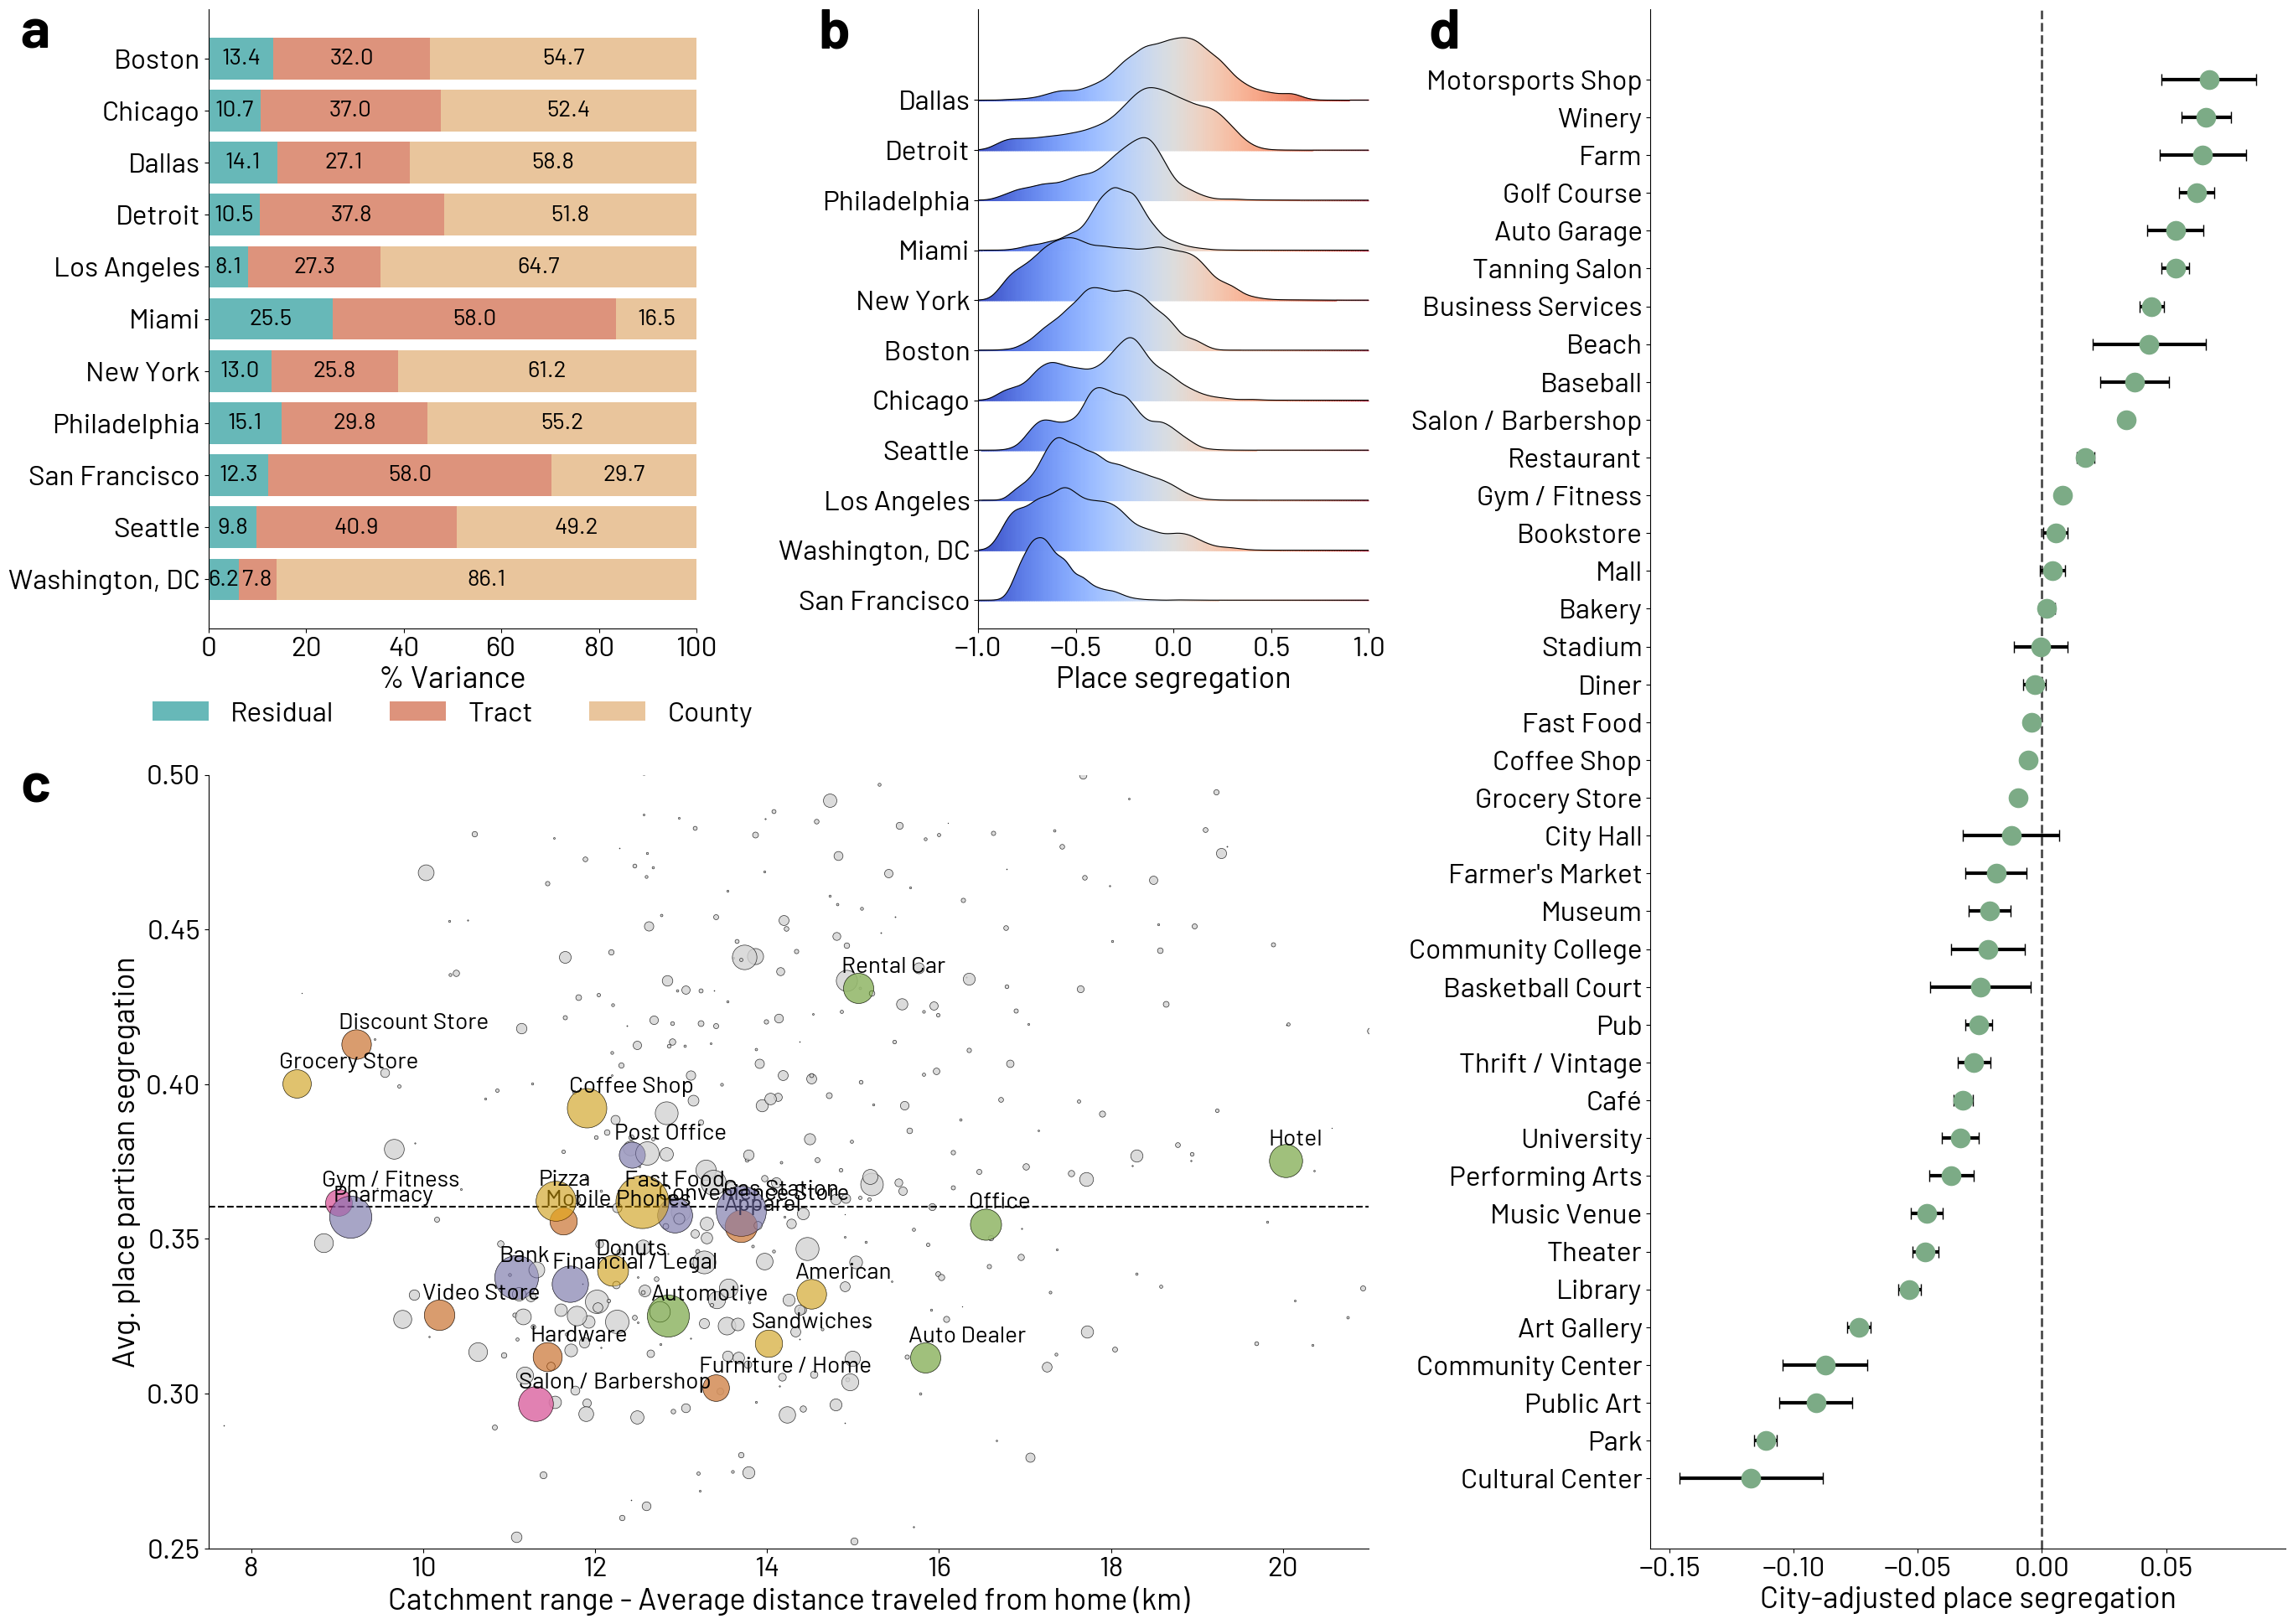

In [6]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import pandas as pd
import numpy as np

# Apply the bundled font immediately before drawing the figure.
from matplotlib import font_manager
font_dirs = ['font/']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
plt.rcParams['font.family'] = 'Barlow'

# --- Create the master figure ---
fig = plt.figure(figsize=(28, 20))

# 2x3 grid
gs = GridSpec(2, 3, figure=fig, width_ratios=[1, 0.8, 1.3], height_ratios=[0.8, 1])

# Define subplots
ax1 = fig.add_subplot(gs[0, 0])        # Plot 1
ax2 = fig.add_subplot(gs[0, 1])        # Plot 2
ax3 = fig.add_subplot(gs[1, 0:2])      # Plot 3 
ax4 = fig.add_subplot(gs[:, 2])        # Plot 4 

# ------------------------------------------------------------
# PLOT 1 — Variance decomposition
# ------------------------------------------------------------
df = vpc.sort_values("city", ascending=False)
levels = ["Residual", "Tract", "County"]
colors = {"Residual":"#269a9a", "Tract":"#cf6545", "County":"#e0ad72"}

bottom = [0]*len(df)
for level in levels:
    bars = ax1.barh(df["city"], df[level], left=bottom,
                    color=colors[level], label=level.capitalize(), alpha=0.7)
    for bar in bars:
        width = bar.get_width()
        if width > 0.05:
            ax1.text(bar.get_x() + width/2, bar.get_y() + bar.get_height()/2,
                     f"{width*100:.1f}", ha='center', va='center',
                     color='black', fontsize=20)
    bottom = [i+j for i,j in zip(bottom, df[level])]

ax1.set_xlabel("% Variance", fontsize=26)
ax1.set_xlim(0, 1)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{int(x*100)}"))
ax1.legend(fontsize=24, loc='lower center', bbox_to_anchor=(0.5, -0.20),
           ncol=len(levels), frameon=False)
ax1.tick_params(axis='both', labelsize=24)
sns.despine(ax=ax1)

# Add subplot label
# ax1.text(-0.15, 1.05, "a", transform=ax1.transAxes, fontsize=44, fontweight='bold', va='top', ha='left')

# ------------------------------------------------------------
# PLOT 2 — Ridge plot of place segregation
# ------------------------------------------------------------
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap

cities = (density[["city", "city_mean"]]
          .drop_duplicates()
          .sort_values("city_mean")["city"].tolist())
cmap = get_cmap("coolwarm")
norm = Normalize(vmin=-1, vmax=1)

for i, city in enumerate(cities):
    city_density = density[density["city"] == city]
    x_vals = city_density["x"].to_numpy()
    y = city_density["density"].to_numpy()
    y_offset = i * 0.8
    for j in range(len(x_vals) - 1):
        x0, x1 = x_vals[j], x_vals[j + 1]
        y0, y1 = y[j] + y_offset, y[j + 1] + y_offset
        color = cmap(norm((x0 + x1) / 2))
        ax2.fill_between([x0, x1], [y_offset, y_offset], [y0, y1], color=color)
    ax2.plot(x_vals, y + y_offset, color="black", linewidth=0.8)

ax2.set_yticks([i * 0.8 for i in range(len(cities))])
ax2.set_yticklabels(cities, fontsize=24)
ax2.set_xlim(-1, 1)
ax2.set_xlabel("Place segregation", fontsize=26)
ax2.tick_params(axis='x', labelsize=24)
sns.despine(ax=ax2)

# ax2.text(-0.15, 1.05, "b", transform=ax2.transAxes, fontsize=44, fontweight='bold', va='top', ha='left')

# ------------------------------------------------------------
# PLOT 3 — Bubble plot
# ------------------------------------------------------------
for _, row in df_plot[df_plot['num_places'] > 0].iterrows():
    ax3.scatter(row['catchment_range'], row['political_segregation'],
                s=row['num_places'] / 5, color='lightgray',
                alpha=0.8, edgecolors='black', linewidth=0.5)

for _, row in df_plot[df_plot['num_places'] > 2400].iterrows():
    color = category_colors.get(row['category'], 'black')
    ax3.scatter(row['catchment_range'], row['political_segregation'],
                s=row['num_places'] / 5, color=color,
                alpha=0.5, edgecolors='black', linewidth=0.3, zorder=3)
    ax3.text(row['catchment_range'] - 200,
             row['political_segregation'] + 0.005,
             row['category'], fontsize=20)

weighted_mean = np.average(df_plot['political_segregation'],
                           weights=df_plot['num_places'])
ax3.axhline(weighted_mean, linestyle='--', color='black')
ax3.axhline(0, linestyle='-', color='black')

ax3.set_xlim(7500, 21000)
ax3.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x/1000)}"))
ax3.set_ylim(0.25, 0.5)
ax3.set_xlabel('Catchment range - Average distance traveled from home (km)', fontsize=26)
ax3.set_ylabel('Avg. place partisan segregation', fontsize=26)
ax3.tick_params(labelsize=24)
sns.despine(ax=ax3)

# ax3.text(-0.03, 1.02, "c", transform=ax3.transAxes, fontsize=44, fontweight='bold', va='top', ha='left')

# ------------------------------------------------------------
# PLOT 4 — Errorbar plot
# ------------------------------------------------------------
ax4.errorbar(summary['mean'], summary['cat'], xerr=summary['se'],
             fmt='o', color='#7CAB86', ecolor='black', markersize=16,
             elinewidth=3, capsize=5)
ax4.axvline(0, color='black', linestyle='--', linewidth=2, alpha=0.7)
ax4.set_xlabel('City-adjusted place segregation', fontsize=26)
ax4.set_yticks(range(len(summary)))
ax4.set_yticklabels(summary['cat'], fontsize=24)
ax4.tick_params(axis='x', labelsize=24)
sns.despine(ax=ax4)

# ax4.text(-0.05, 1.05, "d", transform=ax4.transAxes, fontsize=44, fontweight='bold', va='top', ha='left')


fig.text(0.02, 0.98, "a", fontsize=48, fontweight='bold', va='top', ha='left')
fig.text(0.36, 0.98, "b", fontsize=48, fontweight='bold', va='top', ha='left')
fig.text(0.02, 0.53, "c", fontsize=48, fontweight='bold', va='top', ha='left')
fig.text(0.62, 0.98, "d", fontsize=48, fontweight='bold', va='top', ha='left')

# ------------------------------------------------------------
# Final layout
# ------------------------------------------------------------
plt.tight_layout(pad=3.0, h_pad=4.0, w_pad=2.0)
# fig.savefig("fig_2.svg", format="svg", bbox_inches="tight")
plt.show()
